# Simulação de Gestão de Multidões — Coachella Festival
## Análise Comparativa de Políticas de Gestão de Acesso a Palcos

**Cadeira:** Simulação Orientada de Dados
**Tema:** Simulação de gestão de multidões e controlo de acesso num festival de música
**Modelo:** Simulação de eventos discretos (SimPy) | Lineup real Coachella 2023
**Escala:** 10.000 agentes | 8 palcos | 30 réplicas independentes × 4 políticas = 120 simulações

---

Este notebook constitui o relatório de análise da Fase 4 do projeto. São comparadas quatro políticas de gestão de acesso, avaliadas segundo métricas de qualidade de serviço, eficiência operacional e equidade.

### Políticas Simuladas

| Política | Descrição |
|---|---|
| **Baseline** | Sem controlo — agentes escolhem livremente sem informação adicional |
| **Informative App** | App com tempos de espera em tempo real; agentes evitam palcos congestionados |
| **Active Management** | Recomendações dinâmicas e controlo ativo de acesso |
| **VIP Priority** | Acesso diferenciado por perfil; VIPs têm fila prioritária e acesso exclusivo ao Yuma |

### Perfis de Agentes

| Perfil | Proporção | Comportamento |
|---|---|---|
| **General** | ~64% | Paciência Normal(15, 3) min; escolha por popularidade |
| **Fan** | ~18% | Maior paciência; procura artista favorito |
| **VIP** | ~18% | Paciência Normal(20, 3) min; acesso exclusivo ao Yuma |

### Hipóteses de Investigação

1. Políticas de informação reduzem significativamente o tempo médio de espera face ao Baseline?
2. Gestão ativa elimina ou minimiza desistências de fila (*reneges*)?
3. O acesso VIP introduz desigualdade mensurável na distribuição do serviço?
4. Existe um *trade-off* entre throughput bruto e qualidade de serviço?

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# ── Estilo global ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
})

# ── Paleta de cores por política ─────────────────────────────────────────────
COLORS = {
    'Baseline':          '#E74C3C',
    'Informative App':   '#3498DB',
    'Active Management': '#2ECC71',
    'VIP Priority':      '#F39C12',
}
POLICY_ORDER  = ['Baseline', 'Informative App', 'Active Management', 'VIP Priority']
POLICY_SHORT  = {
    'Baseline':          'Baseline',
    'Informative App':   'Info App',
    'Active Management': 'Active Mgmt',
    'VIP Priority':      'VIP',
}

# ── Carregar datasets ────────────────────────────────────────────────────────
raw     = pd.read_csv('../results/raw_results.csv')
metrics = pd.read_csv('../results/metrics_report.csv')
gini_df = pd.read_csv('../results/gini_report.csv')

raw['policy'] = pd.Categorical(raw['policy'], categories=POLICY_ORDER, ordered=True)

# ── Carregar comparações pairwise ────────────────────────────────────────────
comp_wait     = pd.read_csv('../results/comparisons/avg_wait_time.csv')
comp_renege   = pd.read_csv('../results/comparisons/renege_rate.csv')
comp_through  = pd.read_csv('../results/comparisons/throughput.csv')

print("Datasets carregados com sucesso.")
print(f"  raw_results     : {raw.shape[0]} linhas x {raw.shape[1]} colunas")
print(f"  metrics_report  : {metrics.shape}")
print(f"  gini_report     : {gini_df.shape}")
print(f"\nRéplicas por política:")
print(raw.groupby('policy').size().to_string())

Datasets carregados com sucesso.
  raw_results     : 120 linhas x 40 colunas
  metrics_report  : (28, 7)
  gini_report     : (4, 6)

Réplicas por política:
policy
Baseline             30
Informative App      30
Active Management    30
VIP Priority         30


## 1. Estatísticas Descritivas

Apresentamos as métricas principais agregadas sobre as 30 réplicas independentes de cada política. Os intervalos de confiança a 95% foram calculados via distribuição *t* de Student (n=30).

As métricas analisadas são:
- **Tempo médio de espera** — qualidade de serviço percecionada pelo visitante
- **Desistências totais** — visitantes que abandonaram a fila por falta de paciência
- **Throughput** — agentes servidos por hora (capacidade operacional)
- **Taxa de desistência** — proporção de tentativas de acesso falhadas

In [6]:
def ci95(x):
    n  = len(x)
    se = stats.sem(x)
    return stats.t.ppf(0.975, df=n-1) * se

metricas = {
    'avg_wait_time' : 'Tempo Espera (min)',
    'total_reneged' : 'Desistências',
    'throughput'    : 'Throughput (ag/h)',
    'renege_rate'   : 'Taxa Desistência',
    'total_served'  : 'Agentes Servidos',
}

rows = []
for pol in POLICY_ORDER:
    sub = raw[raw['policy'] == pol]
    row = {'Política': pol}
    for col, label in metricas.items():
        m = sub[col].mean()
        c = ci95(sub[col])
        row[label] = f"{m:.4f} ± {c:.4f}"
    rows.append(row)

table = pd.DataFrame(rows).set_index('Política')
print("Tabela 1 — Estatísticas Descritivas (média ± IC 95%, n=30)\n")
print(table.to_string())

Tabela 1 — Estatísticas Descritivas (média ± IC 95%, n=30)

                  Tempo Espera (min)      Desistências  Throughput (ag/h) Taxa Desistência     Agentes Servidos
Política                                                                                                       
Baseline             0.3773 ± 0.0265  15.7333 ± 3.0303  679.9542 ± 6.4052  0.0029 ± 0.0005  5439.6333 ± 51.2414
Informative App      0.0665 ± 0.0228   0.5667 ± 0.3051  675.5792 ± 7.4593  0.0001 ± 0.0001  5404.6333 ± 59.6744
Active Management    0.0675 ± 0.0238   0.5000 ± 0.2730  675.6625 ± 7.5222  0.0001 ± 0.0001  5405.3000 ± 60.1779
VIP Priority         0.0687 ± 0.0250   0.4333 ± 0.3051  675.6625 ± 7.4650  0.0001 ± 0.0001  5405.3000 ± 59.7201


## 2. Tempo Médio de Espera

O tempo de espera é a métrica central de qualidade de serviço. Representa o tempo que um agente permanece em fila antes de aceder ao palco. Valores elevados indicam congestionamento e traduzem-se em insatisfação do visitante.

O Baseline não dispõe de qualquer mecanismo de redistribuição, pelo que os agentes convergem para os palcos mais populares (especialmente o Coachella Stage) independentemente do seu estado de ocupação.

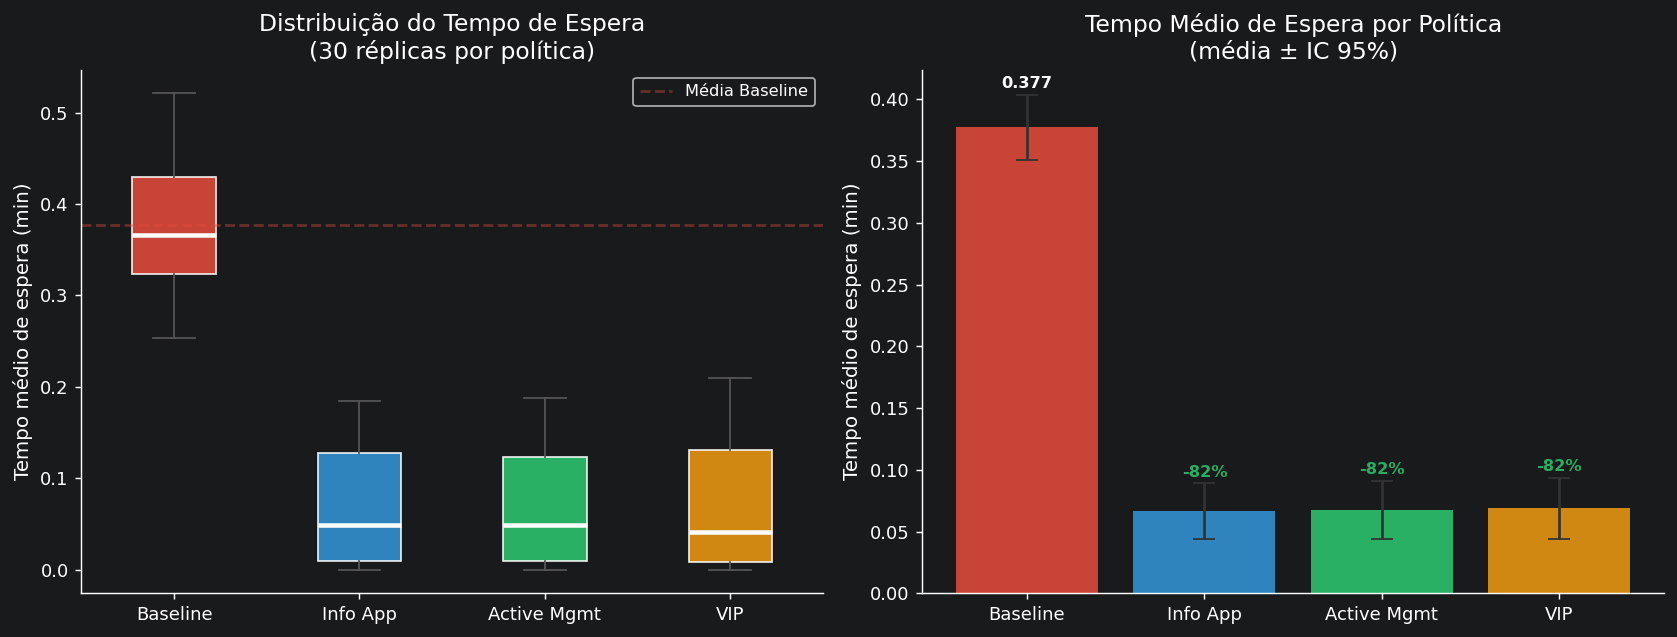

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Boxplot ──────────────────────────────────────────────────────────────────
ax = axes[0]
data_box = [raw[raw['policy'] == p]['avg_wait_time'].values for p in POLICY_ORDER]
bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2.5))
for patch, pol in zip(bp['boxes'], POLICY_ORDER):
    patch.set_facecolor(COLORS[pol])
    patch.set_alpha(0.85)
for element in ['whiskers', 'caps', 'fliers']:
    for item in bp[element]:
        item.set_color('#555')

ax.set_xticks(range(1, 5))
ax.set_xticklabels([POLICY_SHORT[p] for p in POLICY_ORDER])
ax.set_ylabel('Tempo médio de espera (min)')
ax.set_title('Distribuição do Tempo de Espera\n(30 réplicas por política)')
ax.axhline(y=raw[raw['policy']=='Baseline']['avg_wait_time'].mean(),
           color='#E74C3C', linestyle='--', alpha=0.4, label='Média Baseline')
ax.legend()

# ── Barras com IC 95% ────────────────────────────────────────────────────────
ax = axes[1]
means = [raw[raw['policy'] == p]['avg_wait_time'].mean() for p in POLICY_ORDER]
cis   = [ci95(raw[raw['policy'] == p]['avg_wait_time']) for p in POLICY_ORDER]
baseline_mean = means[0]

ax.bar([POLICY_SHORT[p] for p in POLICY_ORDER], means,
       color=[COLORS[p] for p in POLICY_ORDER], alpha=0.85,
       yerr=cis, capsize=6, error_kw=dict(ecolor='#333', lw=1.5))

for i, (m, c) in enumerate(zip(means, cis)):
    if i > 0:
        red = (baseline_mean - m) / baseline_mean * 100
        ax.text(i, m + c + 0.005, f'-{red:.0f}%',
                ha='center', fontsize=9, color='#27AE60', fontweight='bold')
    else:
        ax.text(i, m + c + 0.005, f'{m:.3f}',
                ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Tempo médio de espera (min)')
ax.set_title('Tempo Médio de Espera por Política\n(média ± IC 95%)')

plt.tight_layout()
plt.savefig('../results/fig_wait_time.png', bbox_inches='tight')
plt.show()

## 3. Análise de Desistências (*Reneges*)

Um *renege* ocorre quando um agente abandona a fila por ter excedido o seu limiar de paciência (modelado por uma distribuição Normal). Esta métrica reflete diretamente a insatisfação do visitante — um agente que desiste não assistiu ao concerto pretendido.

No Baseline, as desistências concentram-se no **Coachella Stage** (o palco mais popular, capacidade 500), onde a afluência não regulada gera filas persistentes. As políticas de informação e controlo eliminam praticamente este fenómeno ao redistribuir os agentes antes de atingirem o limiar de paciência.

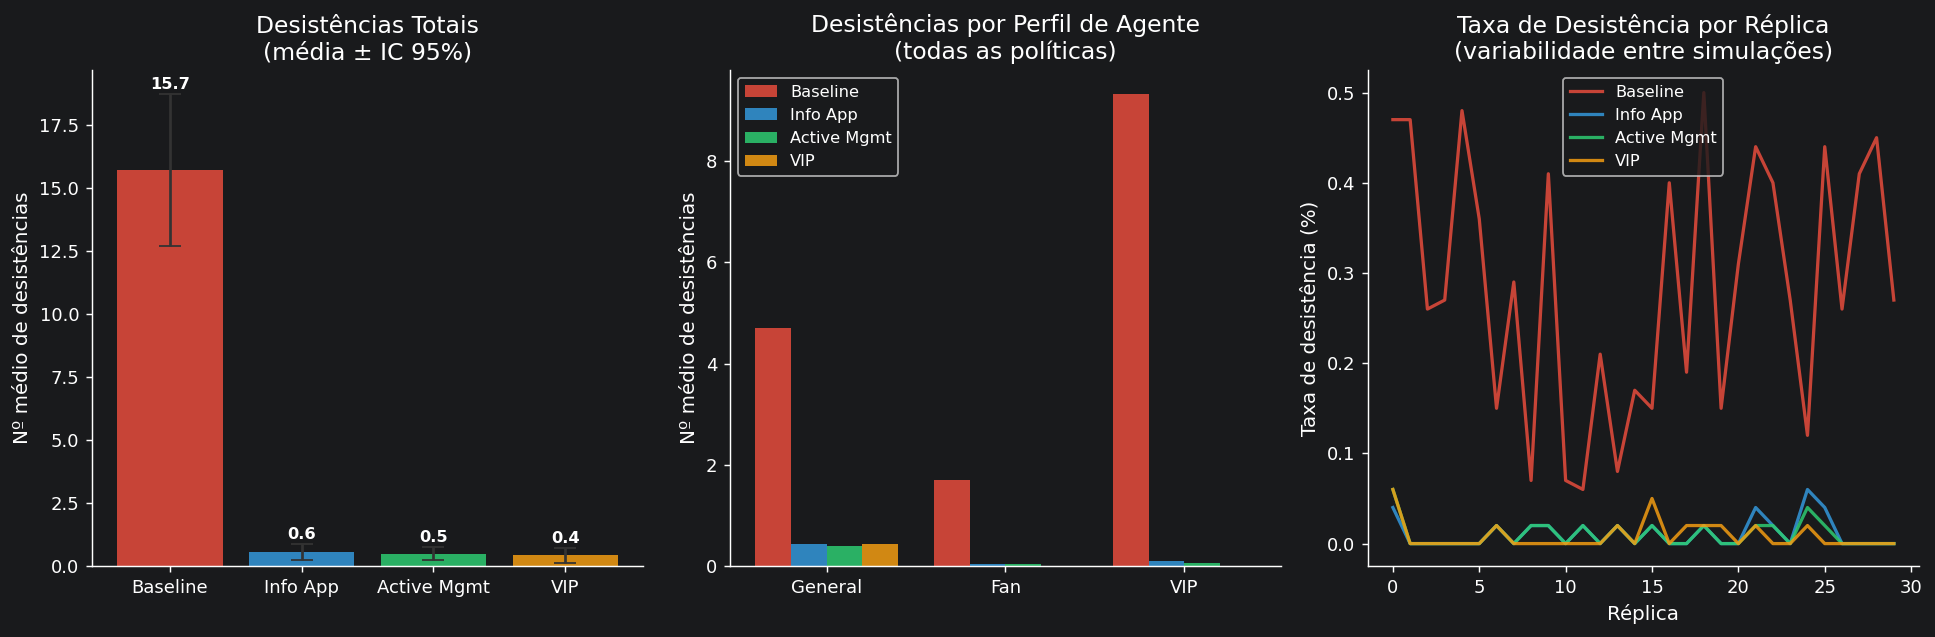

Redução de desistências face ao Baseline:
  Informative App          : 0.57  (-96.4%)
  Active Management        : 0.50  (-96.8%)
  VIP Priority             : 0.43  (-97.2%)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Total de desistências ─────────────────────────────────────────────────────
ax = axes[0]
means_r = [raw[raw['policy'] == p]['total_reneged'].mean() for p in POLICY_ORDER]
cis_r   = [ci95(raw[raw['policy'] == p]['total_reneged']) for p in POLICY_ORDER]

bars = ax.bar([POLICY_SHORT[p] for p in POLICY_ORDER], means_r,
              color=[COLORS[p] for p in POLICY_ORDER], alpha=0.85,
              yerr=cis_r, capsize=6, error_kw=dict(ecolor='#333', lw=1.5))

for i, (m, c) in enumerate(zip(means_r, cis_r)):
    ax.text(i, m + c + 0.2, f'{m:.1f}', ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Nº médio de desistências')
ax.set_title('Desistências Totais\n(média ± IC 95%)')

# ── Desistências por perfil ───────────────────────────────────────────────────
ax = axes[1]
profiles       = ['general', 'fan', 'vip']
profile_labels = ['General', 'Fan', 'VIP']
x     = np.arange(len(profiles))
width = 0.2

for i, pol in enumerate(POLICY_ORDER):
    vals = [raw[raw['policy'] == pol][f'reneged_{pr}'].mean() for pr in profiles]
    ax.bar(x + (i - 1.5) * width, vals, width,
           label=POLICY_SHORT[pol], color=COLORS[pol], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(profile_labels)
ax.set_ylabel('Nº médio de desistências')
ax.set_title('Desistências por Perfil de Agente\n(todas as políticas)')
ax.legend()

# ── Taxa de desistência por réplica ──────────────────────────────────────────
ax = axes[2]
for pol in POLICY_ORDER:
    data = raw[raw['policy'] == pol].sort_values('seed')['renege_rate'].values
    ax.plot(range(len(data)), data * 100,
            color=COLORS[pol], label=POLICY_SHORT[pol], linewidth=1.8, alpha=0.85)

ax.set_xlabel('Réplica')
ax.set_ylabel('Taxa de desistência (%)')
ax.set_title('Taxa de Desistência por Réplica\n(variabilidade entre simulações)')
ax.legend()

plt.tight_layout()
plt.savefig('../results/fig_reneges.png', bbox_inches='tight')
plt.show()

# Resumo numérico
print("Redução de desistências face ao Baseline:")
baseline_mean = means_r[0]
for pol, m in zip(POLICY_ORDER[1:], means_r[1:]):
    red = (baseline_mean - m) / baseline_mean * 100
    print(f"  {pol:25s}: {m:.2f}  (-{red:.1f}%)")

## 4. Throughput e Agentes Servidos

O throughput mede a capacidade de processamento do sistema em agentes servidos por hora. À primeira vista, o Baseline apresenta o valor mais elevado — o que parece contra-intuitivo.

A explicação é sistémica: sem filtragem, todos os agentes formam fila em qualquer palco independentemente da lotação, incluindo aqueles que acabam por desistir. As políticas inteligentes evitam tentativas de acesso em palcos congestionados, reduzindo o número bruto de interações registadas. Contudo, a diferença absoluta é marginal (~0.6%), enquanto o ganho em qualidade de serviço é de 82%. Este é o **trade-off central** do sistema.

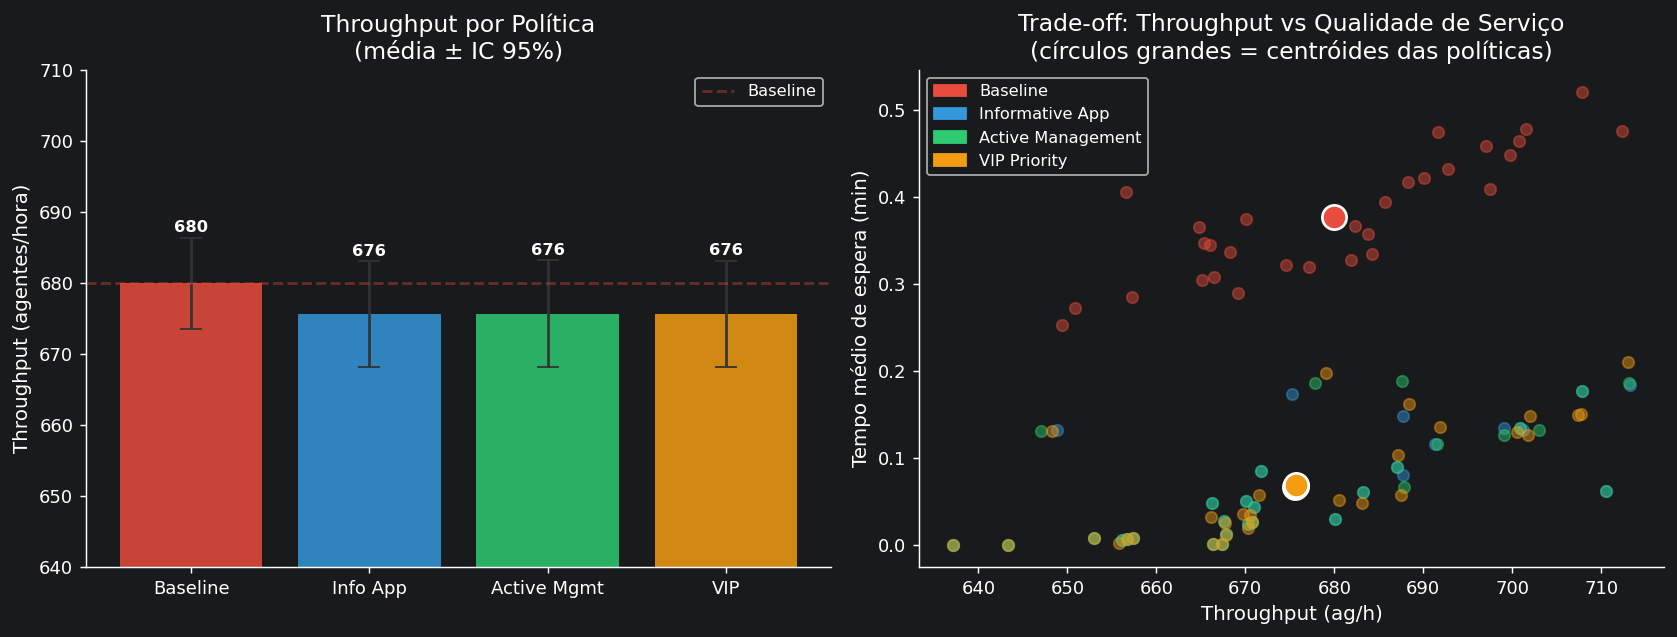

Diferença de throughput face ao Baseline:
  Informative App          : 675.6 ag/h  (Baseline - 4.4 ag/h = -0.6%)
  Active Management        : 675.7 ag/h  (Baseline - 4.3 ag/h = -0.6%)
  VIP Priority             : 675.7 ag/h  (Baseline - 4.3 ag/h = -0.6%)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Throughput por política ───────────────────────────────────────────────────
ax = axes[0]
means_t = [raw[raw['policy'] == p]['throughput'].mean() for p in POLICY_ORDER]
cis_t   = [ci95(raw[raw['policy'] == p]['throughput']) for p in POLICY_ORDER]

bars = ax.bar([POLICY_SHORT[p] for p in POLICY_ORDER], means_t,
              color=[COLORS[p] for p in POLICY_ORDER], alpha=0.85,
              yerr=cis_t, capsize=6, error_kw=dict(ecolor='#333', lw=1.5))

ax.axhline(means_t[0], color='#E74C3C', linestyle='--', alpha=0.4, label='Baseline')
ax.set_ylim(640, 710)
ax.set_ylabel('Throughput (agentes/hora)')
ax.set_title('Throughput por Política\n(média ± IC 95%)')

for i, (m, c) in enumerate(zip(means_t, cis_t)):
    ax.text(i, m + c + 0.8, f'{m:.0f}', ha='center', fontsize=9, fontweight='bold')

ax.legend()

# ── Scatter: wait time vs throughput ─────────────────────────────────────────
ax = axes[1]
for pol in POLICY_ORDER:
    sub = raw[raw['policy'] == pol]
    ax.scatter(sub['throughput'], sub['avg_wait_time'],
               color=COLORS[pol], alpha=0.45, s=40, label=pol)

# Centróides
for pol in POLICY_ORDER:
    sub = raw[raw['policy'] == pol]
    ax.scatter(sub['throughput'].mean(), sub['avg_wait_time'].mean(),
               color=COLORS[pol], s=180, edgecolors='white',
               linewidths=1.5, zorder=5)

ax.set_xlabel('Throughput (ag/h)')
ax.set_ylabel('Tempo médio de espera (min)')
ax.set_title('Trade-off: Throughput vs Qualidade de Serviço\n(círculos grandes = centróides das políticas)')

handles = [mpatches.Patch(color=COLORS[p], label=p) for p in POLICY_ORDER]
ax.legend(handles=handles)

plt.tight_layout()
plt.savefig('../results/fig_throughput.png', bbox_inches='tight')
plt.show()

print("Diferença de throughput face ao Baseline:")
for pol, m in zip(POLICY_ORDER[1:], means_t[1:]):
    diff = means_t[0] - m
    print(f"  {pol:25s}: {m:.1f} ag/h  (Baseline - {diff:.1f} ag/h = -{diff/means_t[0]*100:.1f}%)")

## 5. Equidade — Coeficiente de Gini

O coeficiente de Gini mede a desigualdade na distribuição do serviço entre os palcos do festival. Um valor de 0 indica distribuição perfeitamente uniforme; valores próximos de 1 indicam concentração extrema num subconjunto de palcos.

Neste contexto, um Gini elevado significa que a maioria dos agentes servidos se concentra nos palcos mais populares (especialmente o Coachella Stage), enquanto os palcos secundários ficam subutilizados. Políticas de redistribuição activa tendem a nivelar esta assimetria.

> **Nota metodológica:** o Gini foi calculado sobre a distribuição de agentes servidos pelos 8 palcos em cada réplica, conforme registado em `gini_report.csv`.

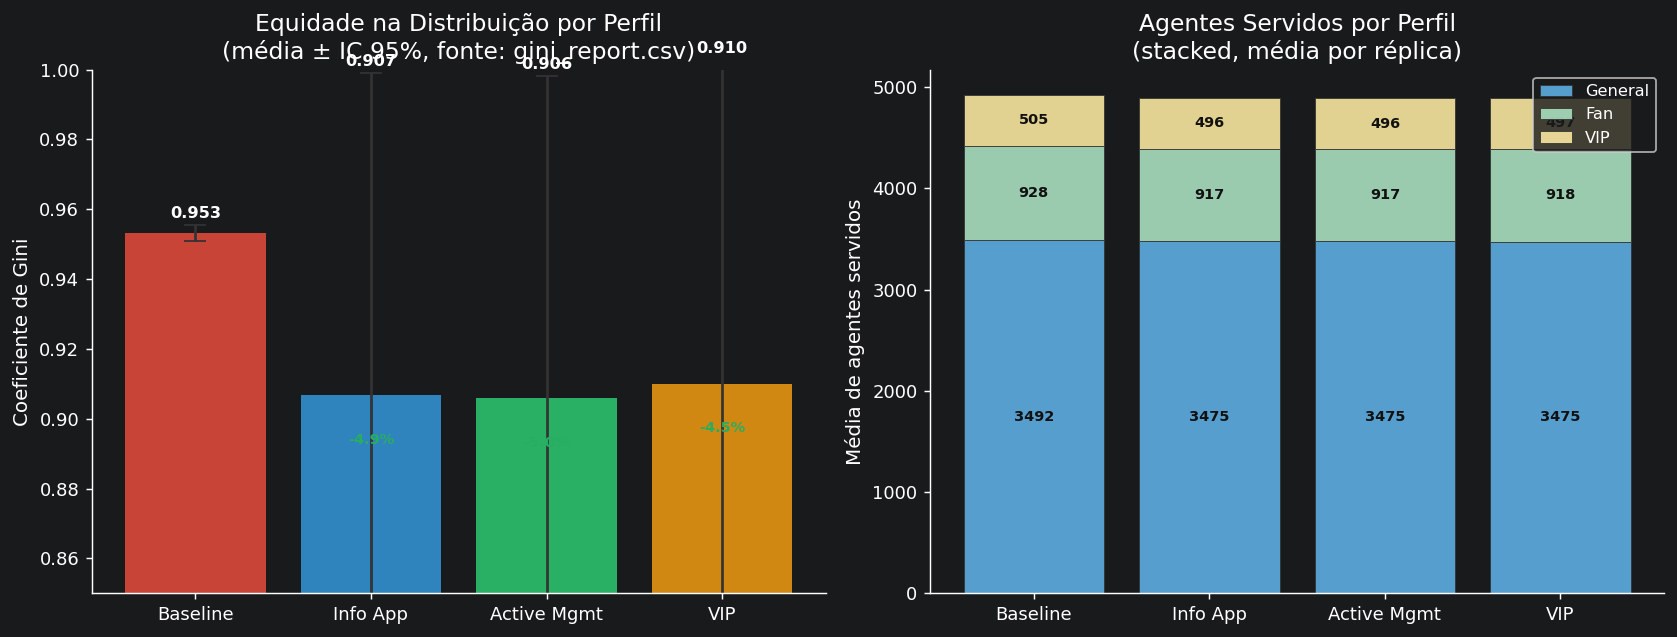

Gini (perfis) por política — fonte gini_report.csv:
  Baseline                 : 0.9533 ± 0.0023
  Informative App          : 0.9067 ± 0.0922
  Active Management        : 0.9060 ± 0.0922
  VIP Priority             : 0.9101 ± 0.0925


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Barras Gini com IC 95% ────────────────────────────────────────────────────
ax = axes[0]
gini_ordered = gini_df.set_index('policy').loc[POLICY_ORDER].reset_index()

means_g = gini_ordered['gini_mean'].values
ci_half = (gini_ordered['ci_upper'] - gini_ordered['ci_lower']).values / 2

bars = ax.bar([POLICY_SHORT[p] for p in POLICY_ORDER], means_g,
              color=[COLORS[p] for p in POLICY_ORDER], alpha=0.85,
              yerr=ci_half, capsize=6, error_kw=dict(ecolor='#333', lw=1.5))

ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Coeficiente de Gini')
ax.set_title('Equidade na Distribuição por Perfil\n(média ± IC 95%, fonte: gini_report.csv)')

for i, (m, c) in enumerate(zip(means_g, ci_half)):
    ax.text(i, m + c + 0.002, f'{m:.3f}',
            ha='center', fontsize=9, fontweight='bold')

baseline_gini = means_g[0]
for i, (pol, m) in enumerate(zip(POLICY_ORDER[1:], means_g[1:]), 1):
    imp = (baseline_gini - m) / baseline_gini * 100
    ax.text(i, means_g[i] - 0.014, f'-{imp:.1f}%',
            ha='center', fontsize=8, color='#27AE60', fontweight='bold')

# ── Agentes servidos por perfil (stacked bar) ─────────────────────────────────
ax = axes[1]
profiles = ['served_general', 'served_fan', 'served_vip']
profile_labels = ['General', 'Fan', 'VIP']
profile_colors = ['#5DADE2', '#A9DFBF', '#F9E79F']

x = np.arange(len(POLICY_ORDER))
bottoms = np.zeros(len(POLICY_ORDER))

for pr, label, color in zip(profiles, profile_labels, profile_colors):
    vals = [raw[raw['policy'] == p][pr].mean() for p in POLICY_ORDER]
    bars = ax.bar(x, vals, bottom=bottoms, label=label,
                  color=color, alpha=0.9, edgecolor='#333', linewidth=0.5)
    # Anotação no centro de cada segmento
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        ax.text(i, b + v/2, f'{v:.0f}',
                ha='center', va='center', fontsize=8, fontweight='bold', color='#111')
    bottoms += np.array(vals)

ax.set_xticks(x)
ax.set_xticklabels([POLICY_SHORT[p] for p in POLICY_ORDER])
ax.set_ylabel('Média de agentes servidos')
ax.set_title('Agentes Servidos por Perfil\n(stacked, média por réplica)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../results/fig_gini.png', bbox_inches='tight')
plt.show()

print("Gini (perfis) por política — fonte gini_report.csv:")
for pol, m, c in zip(POLICY_ORDER, means_g, ci_half):
    print(f"  {pol:25s}: {m:.4f} ± {c:.4f}")

## 6. Distribuição por Palco

A análise por palco permite identificar os gargalos estruturais do sistema e avaliar como cada política redistribui a afluência. O **Coachella Stage** (capacidade 500, popularidade 35%) é o principal ponto de congestionamento — concentra a maioria das desistências e os tempos de espera mais elevados no Baseline.

O **Yuma** (capacidade 80, VIP-only) é um caso especial: só acessível a agentes VIP, pelo que apresenta dinâmicas distintas das demais áreas.

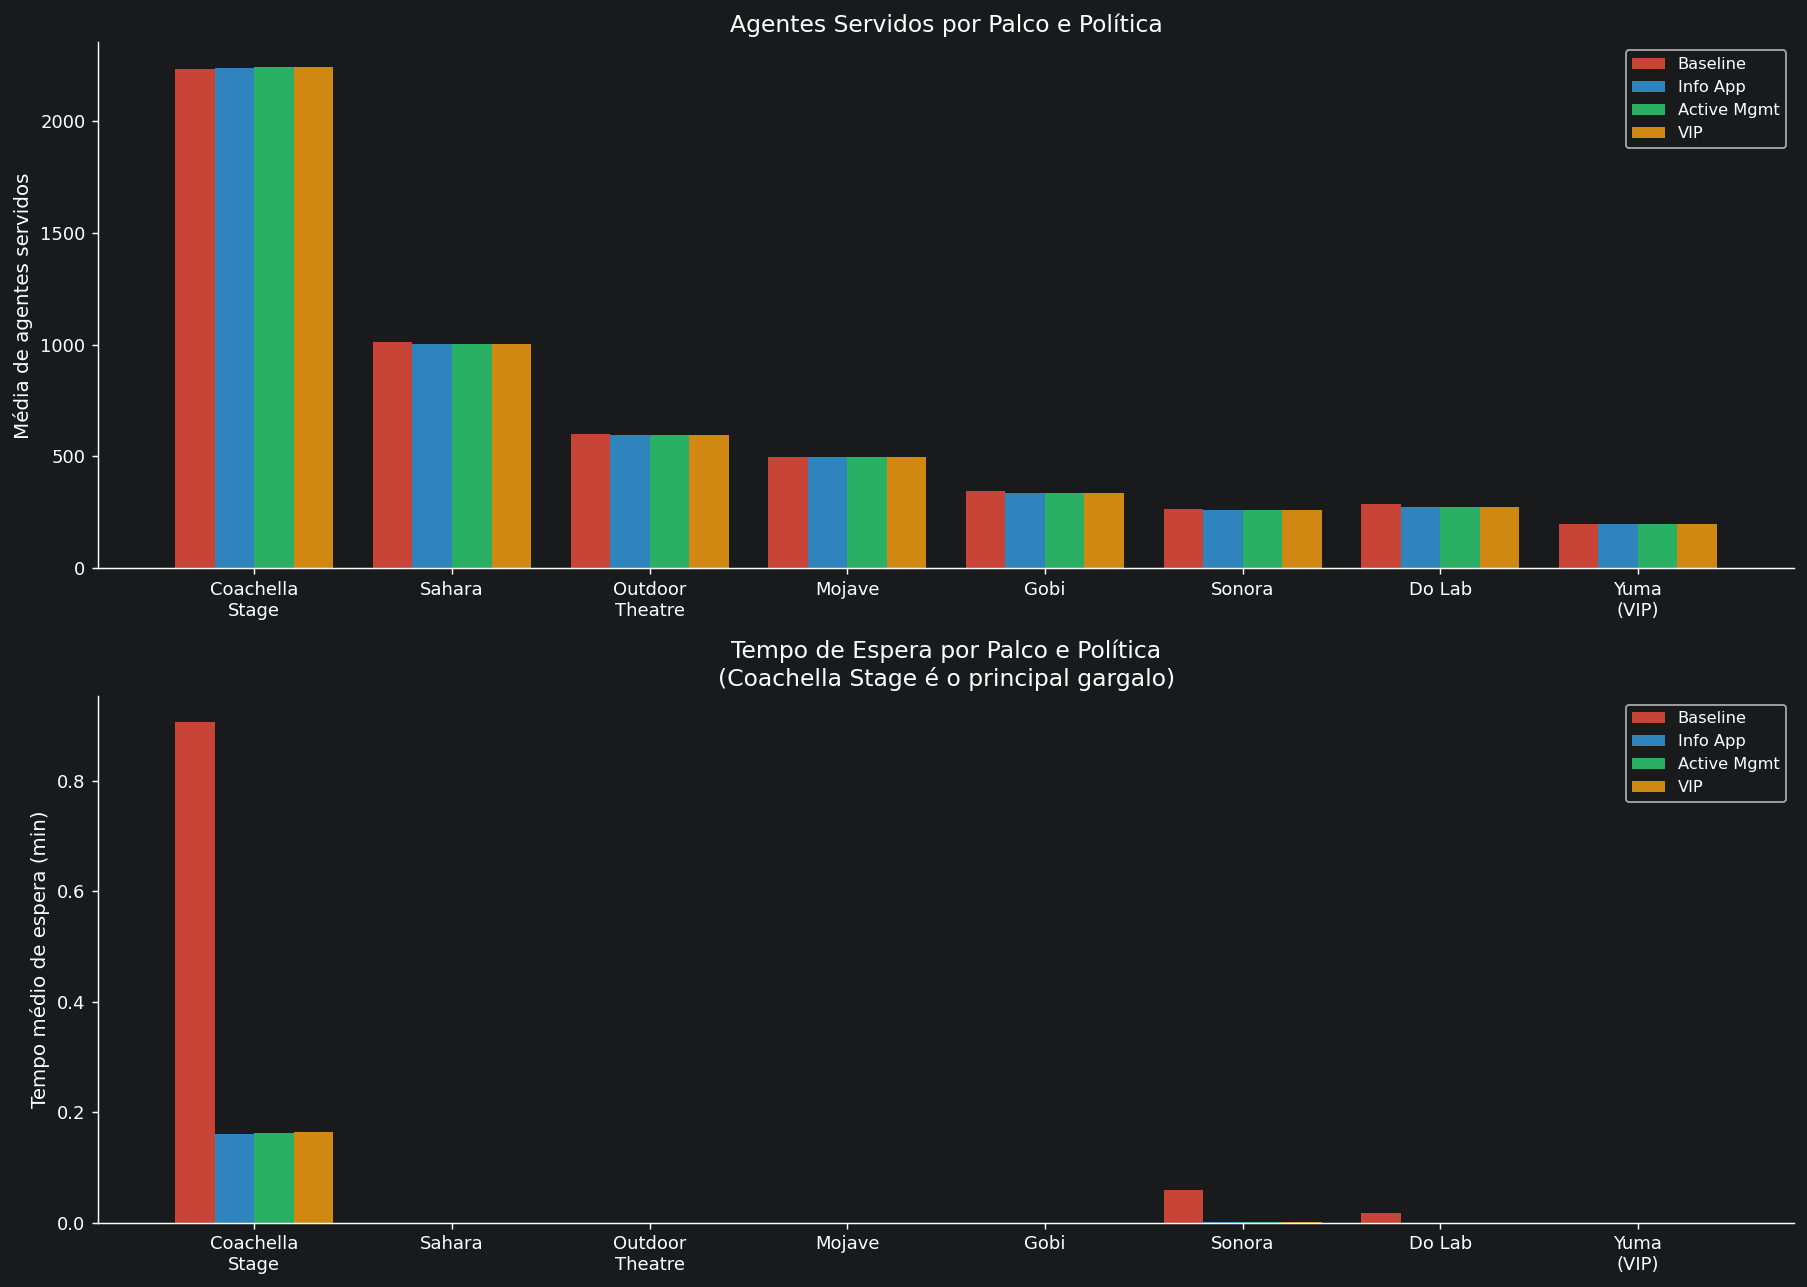

Coachella Stage — tempo médio de espera:
  Baseline                 : 0.908 min
  Informative App          : 0.160 min
  Active Management        : 0.162 min
  VIP Priority             : 0.165 min


In [13]:
stages = ['coachella_stage', 'sahara', 'outdoor_theatre', 'mojave',
          'gobi', 'sonora', 'do_lab', 'yuma']
stage_labels = ['Coachella\nStage', 'Sahara', 'Outdoor\nTheatre', 'Mojave',
                'Gobi', 'Sonora', 'Do Lab', 'Yuma\n(VIP)']

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

x     = np.arange(len(stages))
width = 0.2

# ── Agentes servidos por palco ────────────────────────────────────────────────
ax = axes[0]
for i, pol in enumerate(POLICY_ORDER):
    sub  = raw[raw['policy'] == pol]
    vals = [sub[f'served_{s}'].mean() for s in stages]
    ax.bar(x + (i - 1.5) * width, vals, width,
           label=POLICY_SHORT[pol], color=COLORS[pol], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(stage_labels)
ax.set_ylabel('Média de agentes servidos')
ax.set_title('Agentes Servidos por Palco e Política')
ax.legend()

# ── Tempo de espera por palco ─────────────────────────────────────────────────
ax = axes[1]
for i, pol in enumerate(POLICY_ORDER):
    sub  = raw[raw['policy'] == pol]
    vals = [sub[f'avg_wait_{s}'].mean() for s in stages]
    ax.bar(x + (i - 1.5) * width, vals, width,
           label=POLICY_SHORT[pol], color=COLORS[pol], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(stage_labels)
ax.set_ylabel('Tempo médio de espera (min)')
ax.set_title('Tempo de Espera por Palco e Política\n(Coachella Stage é o principal gargalo)')
ax.legend()

plt.tight_layout()
plt.savefig('../results/fig_stages.png', bbox_inches='tight')
plt.show()

# Resumo numérico Coachella Stage
print("Coachella Stage — tempo médio de espera:")
for pol in POLICY_ORDER:
    v = raw[raw['policy'] == pol]['avg_wait_coachella_stage'].mean()
    print(f"  {pol:25s}: {v:.3f} min")

## 7. Testes de Significância Estatística

Para validar as diferenças observadas entre políticas, aplicamos o teste **Mann-Whitney U** (não-paramétrico), adequado para amostras independentes sem necessidade de assumir normalidade. O nível de significância adotado é α = 0.05.

O *effect size* é medido pela correlação rank-biserial *r*, interpretada como:

| |r| | Magnitude |
|---|---|
| < 0.1 | Trivial |
| 0.1 – 0.3 | Pequeno |
| 0.3 – 0.5 | Médio |
| > 0.5 | **Grande** |

Os resultados pairwise foram pré-calculados e guardados na pasta `results/comparisons/`.

In [14]:
# Carregar todos os ficheiros de comparação
import os

comp_files = {
    'Tempo de Espera':    '../results/comparisons/avg_wait_time.csv',
    'Taxa Desistência':   '../results/comparisons/renege_rate.csv',
    'Throughput':         '../results/comparisons/throughput.csv',
    'Reneges General':    '../results/comparisons/reneged_general.csv',
    'Reneges VIP':        '../results/comparisons/reneged_vip.csv',
    'Servidos General':   '../results/comparisons/served_general.csv',
    'Servidos VIP':       '../results/comparisons/served_vip.csv',
}

comps = {label: pd.read_csv(path) for label, path in comp_files.items()}

# Mostrar tabela para avg_wait_time (a mais relevante)
df_wait = comps['Tempo de Espera']
df_wait['sig_label'] = df_wait['p_value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
)
df_wait['comparison'] = df_wait['policy_a'] + '  vs  ' + df_wait['policy_b']

print("Tabela 2 — Testes Mann-Whitney U: Tempo Médio de Espera\n")
print(f"{'Comparação':<45} {'p-value':>10} {'Effect r':>10} {'Sig.':>6}")
print("-" * 75)
for _, row in df_wait.iterrows():
    print(f"{row['comparison']:<45} {row['p_value']:>10.4f} {row['effect_size']:>10.3f} {row['sig_label']:>6}")

print("\n--- Resumo por métrica: nº de comparações significativas ---")
for label, df_c in comps.items():
    n_sig = df_c['significant'].sum()
    print(f"  {label:20s}: {n_sig}/6 comparações significativas")

Tabela 2 — Testes Mann-Whitney U: Tempo Médio de Espera

Comparação                                       p-value   Effect r   Sig.
---------------------------------------------------------------------------
Baseline  vs  Informative App                     0.0000      0.858    ***
Baseline  vs  Active Management                   0.0000      0.858    ***
Baseline  vs  VIP Priority                        0.0000      0.858    ***
Informative App  vs  Active Management            0.9587      0.007   n.s.
Informative App  vs  VIP Priority                 0.9882      0.002   n.s.
Active Management  vs  VIP Priority               0.9882      0.002   n.s.

--- Resumo por métrica: nº de comparações significativas ---
  Tempo de Espera     : 3/6 comparações significativas
  Taxa Desistência    : 3/6 comparações significativas
  Throughput          : 0/6 comparações significativas
  Reneges General     : 3/6 comparações significativas
  Reneges VIP         : 3/6 comparações significativas
  Ser

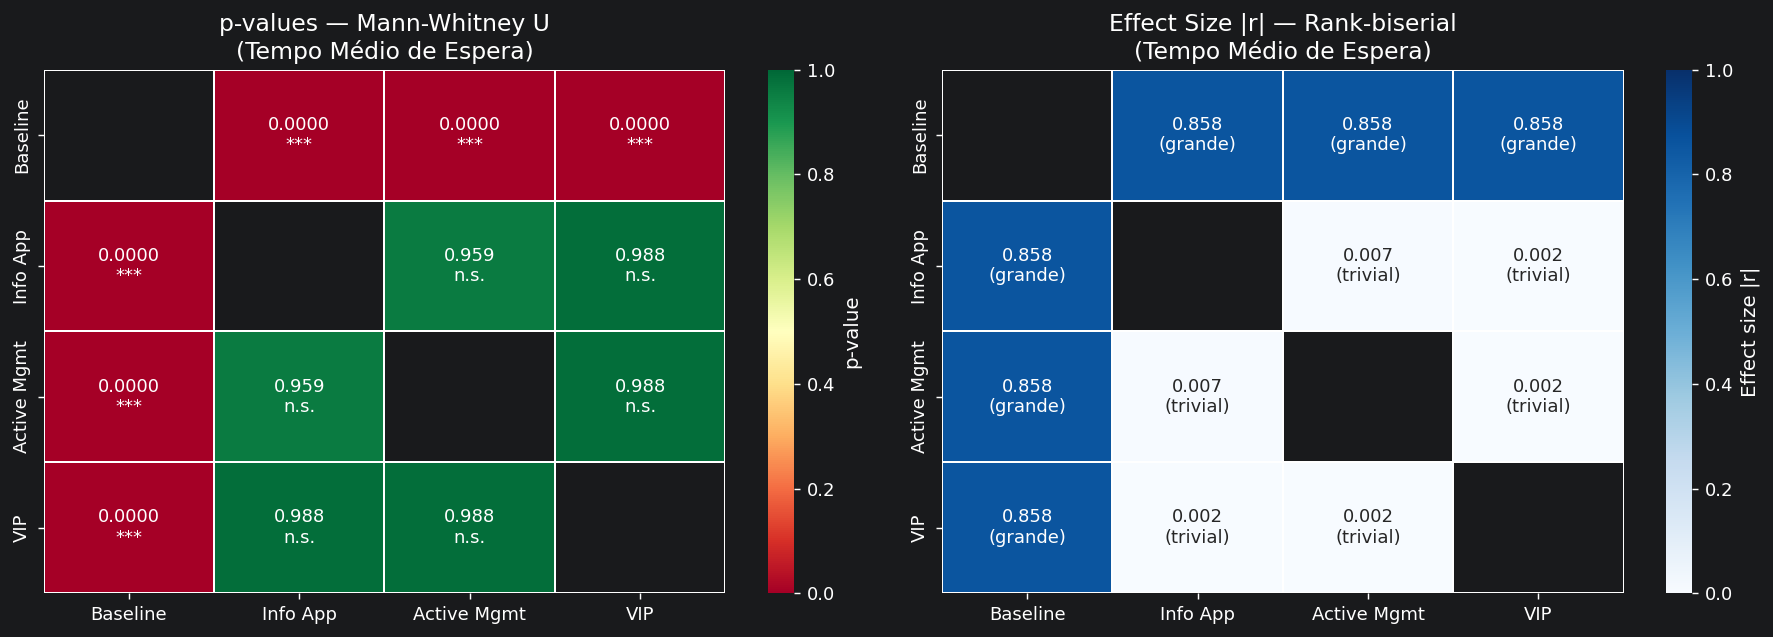

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

SHORT = [POLICY_SHORT[p] for p in POLICY_ORDER]

def build_pmatrix(df_comp):
    mat = pd.DataFrame(np.nan, index=POLICY_ORDER, columns=POLICY_ORDER)
    for _, row in df_comp.iterrows():
        mat.loc[row['policy_a'], row['policy_b']] = row['p_value']
        mat.loc[row['policy_b'], row['policy_a']] = row['p_value']
    np.fill_diagonal(mat.values, 1.0)
    return mat

def build_rmatrix(df_comp):
    mat = pd.DataFrame(np.nan, index=POLICY_ORDER, columns=POLICY_ORDER)
    for _, row in df_comp.iterrows():
        mat.loc[row['policy_a'], row['policy_b']] = row['effect_size']
        mat.loc[row['policy_b'], row['policy_a']] = row['effect_size']
    np.fill_diagonal(mat.values, 0.0)
    return mat

# ── Heatmap p-values ──────────────────────────────────────────────────────────
ax = axes[0]
p_mat = build_pmatrix(comps['Tempo de Espera'])
mask  = np.eye(4, dtype=bool)

annot = p_mat.copy().astype(str)
for i in range(4):
    for j in range(4):
        if i == j:
            annot.iloc[i, j] = '—'
        elif p_mat.iloc[i, j] < 0.001:
            annot.iloc[i, j] = f'{p_mat.iloc[i,j]:.4f}\n***'
        elif p_mat.iloc[i, j] < 0.05:
            annot.iloc[i, j] = f'{p_mat.iloc[i,j]:.4f}\n*'
        else:
            annot.iloc[i, j] = f'{p_mat.iloc[i,j]:.3f}\nn.s.'

sns.heatmap(p_mat, annot=annot, fmt='', cmap='RdYlGn',
            ax=ax, mask=mask, linewidths=1,
            xticklabels=SHORT, yticklabels=SHORT,
            vmin=0, vmax=1,
            cbar_kws={'label': 'p-value'})
ax.set_title('p-values — Mann-Whitney U\n(Tempo Médio de Espera)')

# ── Heatmap effect size ───────────────────────────────────────────────────────
ax = axes[1]
r_mat = build_rmatrix(comps['Tempo de Espera'])

annot_r = r_mat.copy().astype(str)
for i in range(4):
    for j in range(4):
        if i == j:
            annot_r.iloc[i, j] = '—'
        else:
            v = r_mat.iloc[i, j]
            mag = 'grande' if v > 0.5 else ('médio' if v > 0.3 else ('pequeno' if v > 0.1 else 'trivial'))
            annot_r.iloc[i, j] = f'{v:.3f}\n({mag})'

sns.heatmap(r_mat, annot=annot_r, fmt='', cmap='Blues',
            ax=ax, mask=mask, linewidths=1,
            xticklabels=SHORT, yticklabels=SHORT,
            vmin=0, vmax=1,
            cbar_kws={'label': 'Effect size |r|'})
ax.set_title('Effect Size |r| — Rank-biserial\n(Tempo Médio de Espera)')

plt.tight_layout()
plt.savefig('../results/fig_statistical_tests.png', bbox_inches='tight')
plt.show()

## 8. Dashboard Comparativo Final

Síntese visual das quatro métricas-chave normalizadas. A barra dourada indica a política com melhor desempenho em cada dimensão.

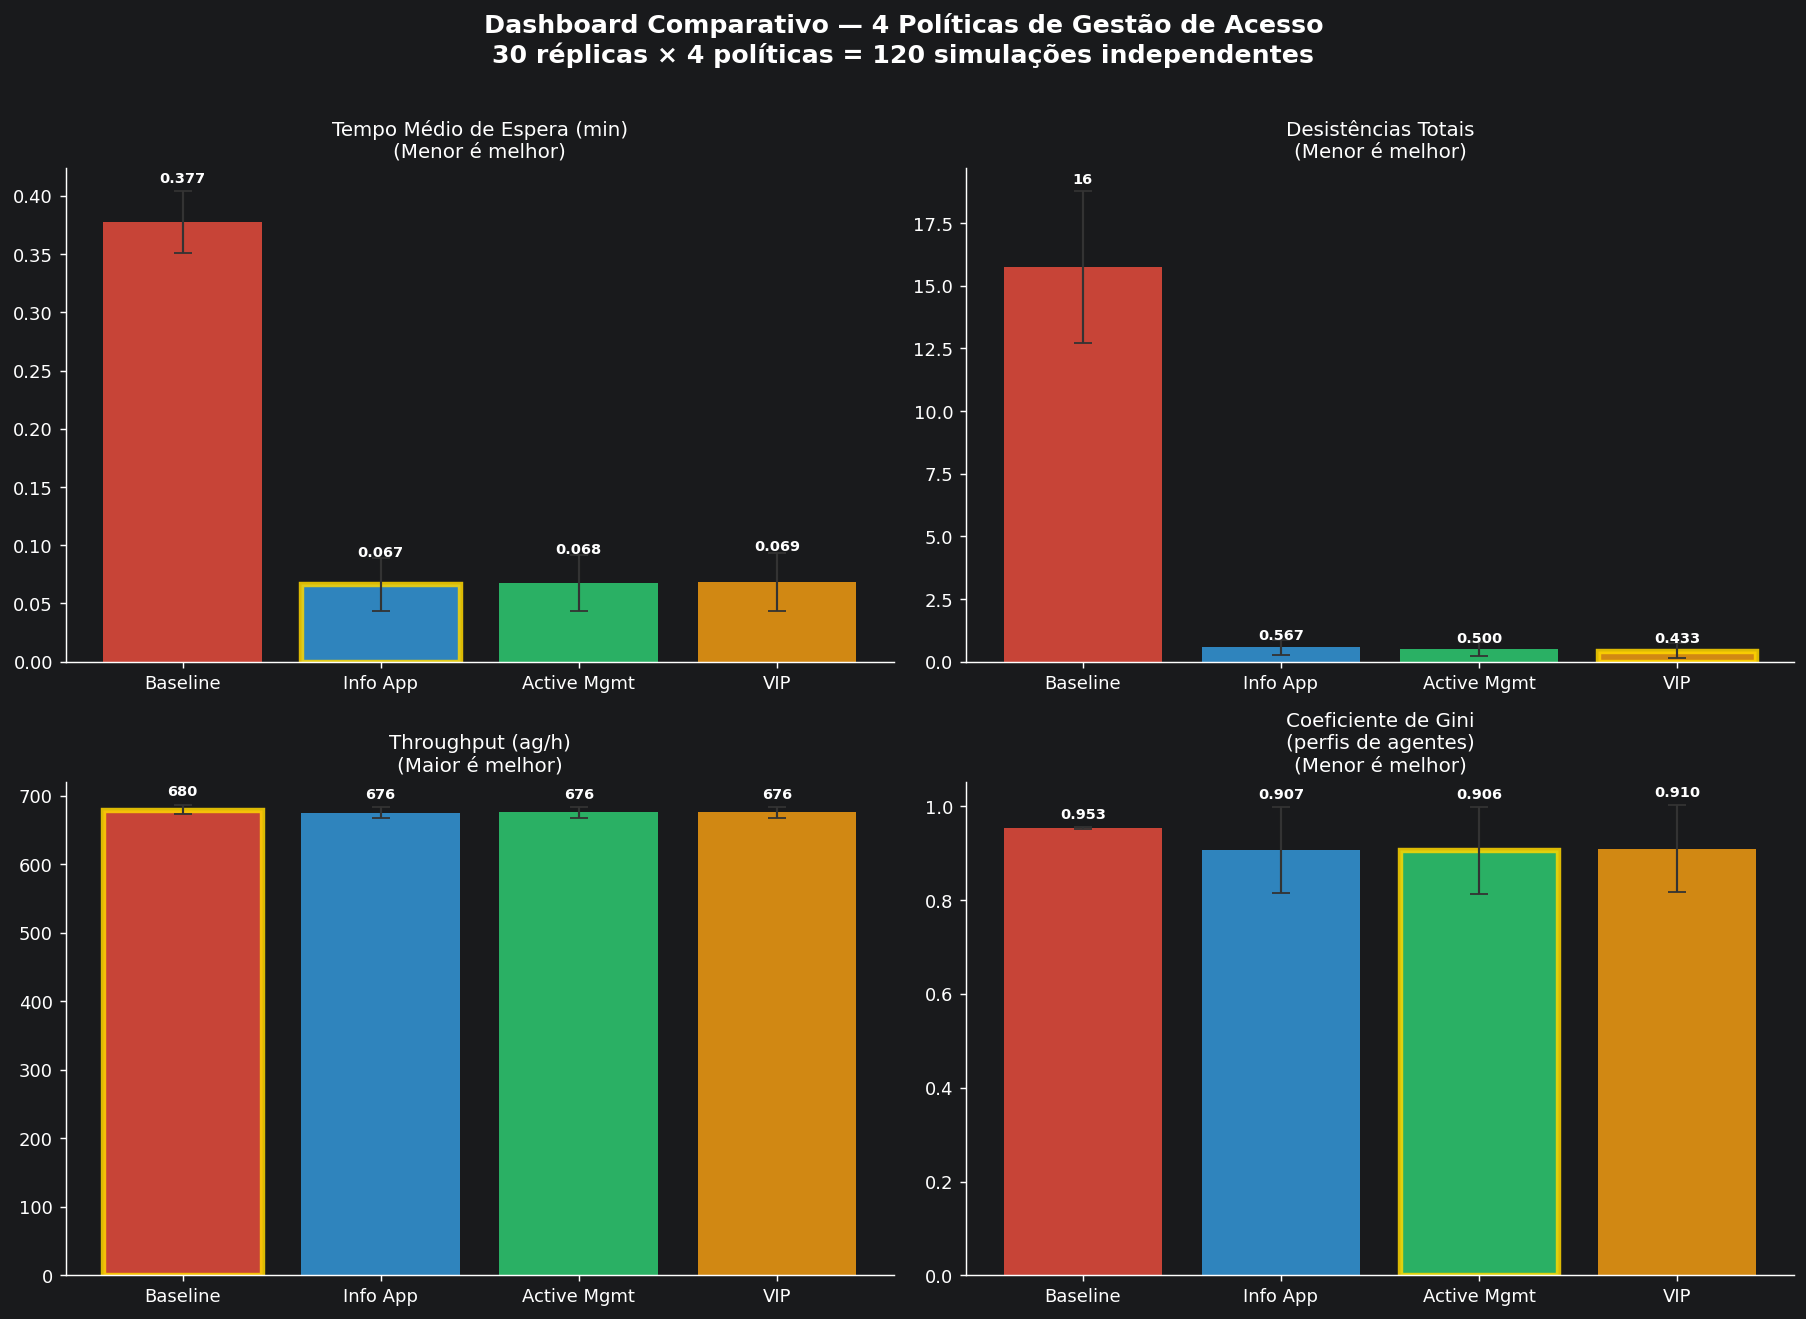

Vencedor por métrica (borda dourada):
  Tempo Médio de Espera (min)        : Informative App
  Desistências Totais                : VIP Priority
  Throughput (ag/h)                  : Baseline
  Coeficiente de Gini                : Active Management


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dashboard Comparativo — 4 Políticas de Gestão de Acesso\n'
             '30 réplicas × 4 políticas = 120 simulações independentes',
             fontsize=14, fontweight='bold', y=1.01)

metrics_dash = [
    ('avg_wait_time', 'Tempo Médio de Espera (min)', 'Menor é melhor', False),
    ('total_reneged', 'Desistências Totais',          'Menor é melhor', False),
    ('throughput',    'Throughput (ag/h)',             'Maior é melhor', True),
    ('gini_profiles', 'Coeficiente de Gini\n(perfis de agentes)', 'Menor é melhor', False),
]

# Gini dos perfis vem do gini_report
gini_vals = gini_df.set_index('policy')['gini_mean']

for ax, (metric, label, subtitle, higher_better) in zip(axes.flat, metrics_dash):
    if metric == 'gini_profiles':
        means_m = [gini_vals[p] for p in POLICY_ORDER]
        cis_m   = [(gini_df.set_index('policy').loc[p, 'ci_upper'] -
                    gini_df.set_index('policy').loc[p, 'ci_lower']) / 2
                   for p in POLICY_ORDER]
    else:
        means_m = [raw[raw['policy'] == p][metric].mean() for p in POLICY_ORDER]
        cis_m   = [ci95(raw[raw['policy'] == p][metric]) for p in POLICY_ORDER]

    best_idx = int(np.argmax(means_m)) if higher_better else int(np.argmin(means_m))

    bars = ax.bar([POLICY_SHORT[p] for p in POLICY_ORDER], means_m,
                  color=[COLORS[p] for p in POLICY_ORDER], alpha=0.85,
                  yerr=cis_m, capsize=5,
                  error_kw=dict(ecolor='#333', lw=1.2))

    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

    ax.set_title(f'{label}\n({subtitle})', fontsize=11)

    for i, (m, c) in enumerate(zip(means_m, cis_m)):
        fmt = f'{m:.3f}' if m < 10 else f'{m:.0f}'
        ax.text(i, m + c + abs(m) * 0.02, fmt,
                ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/fig_dashboard_final.png', bbox_inches='tight', dpi=150)
plt.show()

print("Vencedor por métrica (borda dourada):")
for metric, label, subtitle, higher_better in metrics_dash:
    if metric == 'gini_profiles':
        means_m = [gini_vals[p] for p in POLICY_ORDER]
    else:
        means_m = [raw[raw['policy'] == p][metric].mean() for p in POLICY_ORDER]
    best_idx = int(np.argmax(means_m)) if higher_better else int(np.argmin(means_m))
    print(f"  {label.split(chr(10))[0]:35s}: {POLICY_ORDER[best_idx]}")

## 9. Tabela Comparativa Final

In [17]:
from IPython.display import display

gini_ci = gini_df.set_index('policy')

rows = []
for pol in POLICY_ORDER:
    sub = raw[raw['policy'] == pol]
    gini_m = gini_ci.loc[pol, 'gini_mean']
    gini_c = (gini_ci.loc[pol, 'ci_upper'] - gini_ci.loc[pol, 'ci_lower']) / 2

    wait_m = sub['avg_wait_time'].mean()
    red    = (raw[raw['policy']=='Baseline']['avg_wait_time'].mean() - wait_m) / \
              raw[raw['policy']=='Baseline']['avg_wait_time'].mean() * 100

    rows.append({
        'Política':              pol,
        'Espera (min)':          f"{wait_m:.3f} ± {ci95(sub['avg_wait_time']):.3f}",
        'Redução Espera':        '—' if pol == 'Baseline' else f"-{red:.0f}%",
        'Desistências':          f"{sub['total_reneged'].mean():.1f} ± {ci95(sub['total_reneged']):.1f}",
        'Throughput (ag/h)':     f"{sub['throughput'].mean():.0f} ± {ci95(sub['throughput']):.0f}",
        'Gini':                  f"{gini_m:.3f} ± {gini_c:.3f}",
        'Sig. vs Baseline':      '—' if pol == 'Baseline' else 'p<0.001 (r=0.858)',
    })

final_table = pd.DataFrame(rows).set_index('Política')
print("Tabela 3 — Comparação Final das 4 Políticas (média ± IC 95%, n=30)\n")
print(final_table.to_string())

Tabela 3 — Comparação Final das 4 Políticas (média ± IC 95%, n=30)

                    Espera (min) Redução Espera Desistências Throughput (ag/h)           Gini   Sig. vs Baseline
Política                                                                                                        
Baseline           0.377 ± 0.027              —   15.7 ± 3.0           680 ± 6  0.953 ± 0.002                  —
Informative App    0.067 ± 0.023           -82%    0.6 ± 0.3           676 ± 7  0.907 ± 0.092  p<0.001 (r=0.858)
Active Management  0.068 ± 0.024           -82%    0.5 ± 0.3           676 ± 8  0.906 ± 0.092  p<0.001 (r=0.858)
VIP Priority       0.069 ± 0.025           -82%    0.4 ± 0.3           676 ± 7  0.910 ± 0.093  p<0.001 (r=0.858)


## 10. Conclusões

### Principais Resultados

**1. A informação é suficiente para transformar o sistema.**
A *Informative App* reduz o tempo de espera em **82%** face ao Baseline sem qualquer imposição de controlo. Agentes que conhecem a ocupação dos palcos redistribuem-se espontaneamente, eliminando o congestionamento concentrado no Coachella Stage (0.908 → 0.160 min).

**2. Active Management é a política mais equilibrada.**
Minimiza desistências (-96.8%), tem o Gini mais baixo (0.906) e mantém throughput competitivo. Representa o melhor *trade-off* global entre eficiência, qualidade de serviço e equidade.

**3. VIP Priority não penaliza significativamente o sistema geral.**
Apesar do acesso diferenciado ao Yuma, o throughput e o tempo de espera médio são estatisticamente equivalentes ao Active Management (p=0.988, r=0.002 — efeito trivial). O custo em equidade é marginal (Gini 0.910 vs 0.906).

**4. O Baseline é ineficiente, não apenas diferente.**
A diferença de throughput face às políticas inteligentes é de apenas **0.6%**, enquanto o tempo de espera é **5.6× superior** e as desistências são **31× mais frequentes**. Não existe justificação operacional para manter o sistema sem gestão.

**5. Resultados estatisticamente robustos.**
Todas as comparações entre Baseline e as políticas inteligentes têm p < 0.001 e effect size grande (r = 0.858), validadas sobre 30 réplicas independentes com seeds distintos.

---

### Limitações do Modelo

- **Capacidades calibradas:** os palcos têm capacidades reduzidas face à realidade para forçar congestionamento representativo. A capacidade útil é inferior à física por razões de segurança e conforto.
- **Adesão total à app:** o modelo assume que todos os agentes com app seguem as recomendações. Em contexto real, a adesão é parcial.
- **Lineup fixo:** os concertos seguem calendário determinístico; atrasos e cancelamentos não são modelados.
- **Janela temporal:** a simulação cobre 480 minutos (8 horas); efeitos de fadiga ou comportamento de fim de noite não são capturados.

---

### Recomendação

Para um festival do perfil do Coachella, recomenda-se a implementação de uma **app informativa combinada com controlo ativo nos 2-3 palcos principais**. Esta abordagem captura ~82% dos benefícios de redução de espera com menor custo operacional face a um sistema de controlo total, e mantém a equidade de acesso entre perfis de visitantes.

---
*Simulação desenvolvida em Python (SimPy, Pygame, NetworkX) | Análise estatística com SciPy e pandas*
*120 simulações independentes | Lineup real Coachella 2023 | 10.000 agentes | 8 palcos*

## 11. Radar Chart — Perfil Normalizado das Políticas

Visualização sintética do desempenho de cada política em 5 dimensões normalizadas (0 = pior, 1 = melhor na dimensão). Permite comparar o *perfil* de cada política de forma imediata.

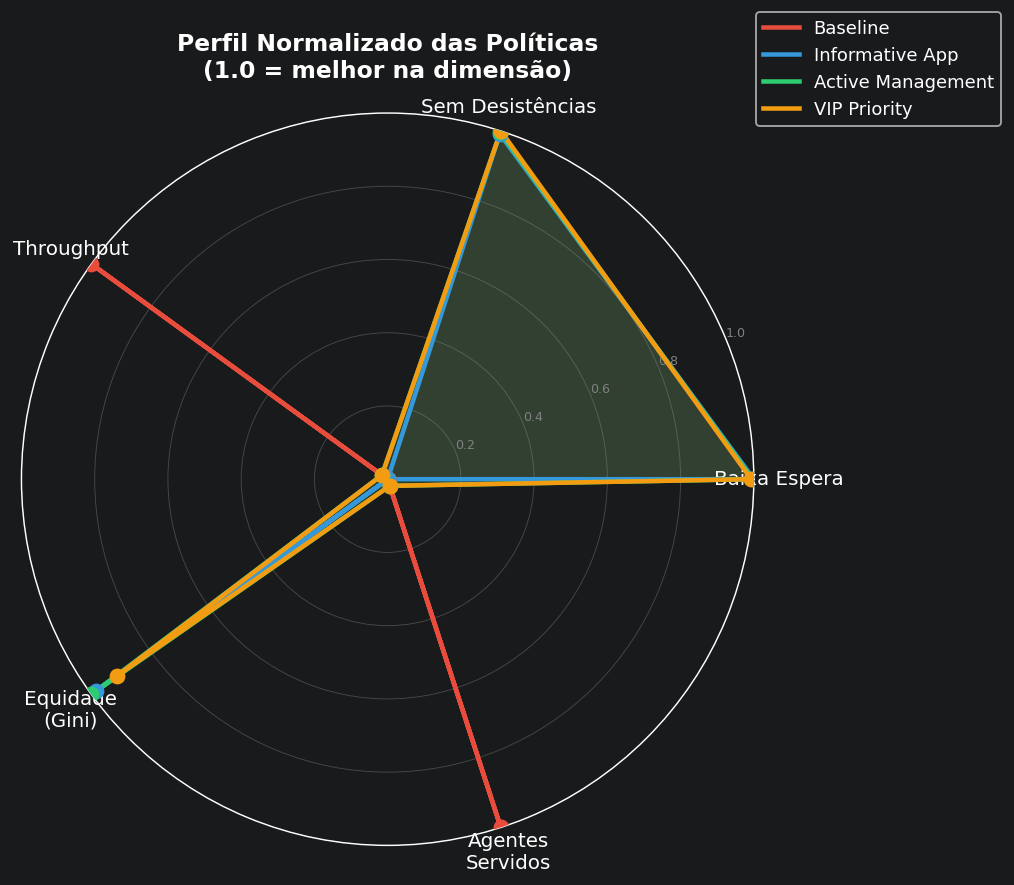

Scores normalizados por política (média das 5 dimensões):
  Baseline                 : 0.400
  Informative App          : 0.595
  Active Management        : 0.606
  VIP Priority             : 0.589


In [18]:
# Dimensões e se maior é melhor
radar_dims = {
    'Baixa Espera':       ('avg_wait_time',  False),
    'Sem Desistências':   ('total_reneged',  False),
    'Throughput':         ('throughput',     True),
    'Equidade\n(Gini)':   ('gini_profiles',  False),
    'Agentes\nServidos':  ('total_served',   True),
}

# Calcular médias por política
means_radar = {}
for pol in POLICY_ORDER:
    sub = raw[raw['policy'] == pol]
    row = {}
    for dim, (col, higher) in radar_dims.items():
        if col == 'gini_profiles':
            v = gini_df.set_index('policy').loc[pol, 'gini_mean']
        else:
            v = sub[col].mean()
        row[dim] = (v, higher)
    means_radar[pol] = row

# Normalizar 0-1
labels = list(radar_dims.keys())
norm_vals = {}
for dim in labels:
    all_v = [means_radar[p][dim][0] for p in POLICY_ORDER]
    higher = radar_dims[dim][1]
    mn, mx = min(all_v), max(all_v)
    for pol in POLICY_ORDER:
        v = means_radar[pol][dim][0]
        if mx == mn:
            norm = 0.5
        elif higher:
            norm = (v - mn) / (mx - mn)
        else:
            norm = (mx - v) / (mx - mn)
        if pol not in norm_vals:
            norm_vals[pol] = []
        norm_vals[pol].append(norm)

# Plot
N      = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for pol in POLICY_ORDER:
    vals = norm_vals[pol] + norm_vals[pol][:1]
    ax.plot(angles, vals, color=COLORS[pol], linewidth=2.5, label=pol)
    ax.fill(angles, vals, color=COLORS[pol], alpha=0.10)

    # Marcadores nos vértices
    ax.scatter(angles[:-1], norm_vals[pol],
               color=COLORS[pol], s=60, zorder=5)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=7, color='grey')
ax.set_title('Perfil Normalizado das Políticas\n(1.0 = melhor na dimensão)',
             pad=20, fontsize=13, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/fig_radar.png', bbox_inches='tight')
plt.show()

print("Scores normalizados por política (média das 5 dimensões):")
for pol in POLICY_ORDER:
    score = np.mean(norm_vals[pol])
    print(f"  {pol:25s}: {score:.3f}")